# Análisis de Datos de Viviendas

In [1]:
import pandas as pd
datos = pd.read_csv("housing.csv")

Las primeras 5 filas del DataFrame

In [2]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Se crea una gráfico  mostrando la ubicación de las viviendas

<Axes: xlabel='latitude', ylabel='longitude'>

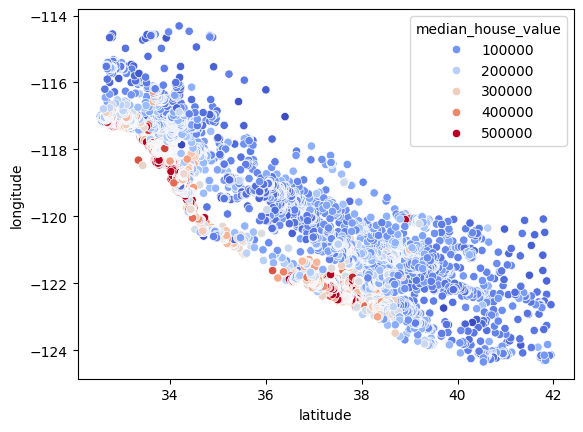

In [4]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value",
               palette="coolwarm")

Este gráfico de dispersión muestra la ubicación de las viviendas, con el color y tamaño de los puntos indicando el ingreso mediano de la zona.

TypeError: cannot convert the series to <class 'float'>

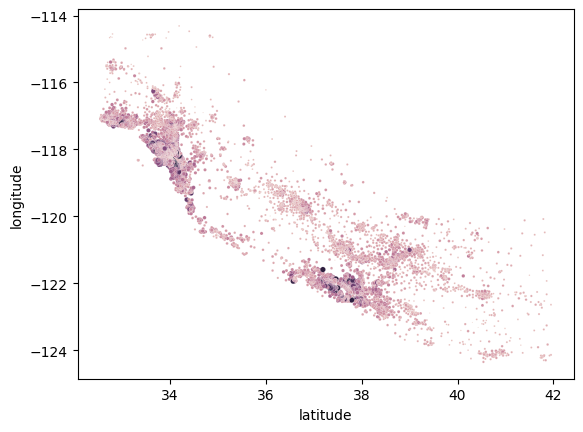

In [5]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_income",
               s=datos["median_income"])

Esta celda selecciona las columnas de latitud, longitud e ingreso mediano para usarlas en el análisis de clustering.

In [6]:
datos.loc[:, ["latitude", "longitude", "median_income"]]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


Aquí se utiliza el algoritmo K-Means para agrupar las viviendas en 6 segmentos basándose en su latitud, longitud e ingreso mediano.

In [7]:
from sklearn.cluster import KMeans
x = datos.loc[:, ["latitude", "longitude", "median_income"]]
modelo = KMeans(n_clusters=6)
predicciones = modelo.fit_predict(x)

Esta celda muestra el tamaño de las `predicciones`, que es el número de asignaciones de cluster realizadas.

In [8]:
predicciones.shape

(20640,)

Se añade la columna `segmento_economico` al DataFrame `x`, que contiene el cluster asignado a cada vivienda.

In [9]:
x["segmento_economico"] = predicciones

Esta celda muestra el DataFrame x con la nueva columna

In [10]:
x

,latitude,longitude,median_income,segmento_economico
0,37.88,-122.23,8.3252,4
1,37.86,-122.22,8.3014,4
2,37.85,-122.24,7.2574,4
3,37.85,-122.25,5.6431,1
4,37.85,-122.25,3.8462,1
...,...,...,...,...
20635,39.48,-121.09,1.5603,5
20636,39.49,-121.21,2.5568,5
20637,39.43,-121.22,1.7000,5
20638,39.43,-121.32,1.8672,5


Aquí se cuenta cuántas viviendas hay en cada segmento económico.

In [11]:
x["segmento_economico"].value_counts()

,count
segmento_economico,
0,6584
3,4625
5,4521
1,3479
2,760
4,671


Este gráfico  muestra las viviendas, coloreadas según el segmento económico al que pertenecen, para visualizar la distribución de clusters.

<Axes: xlabel='latitude', ylabel='longitude'>

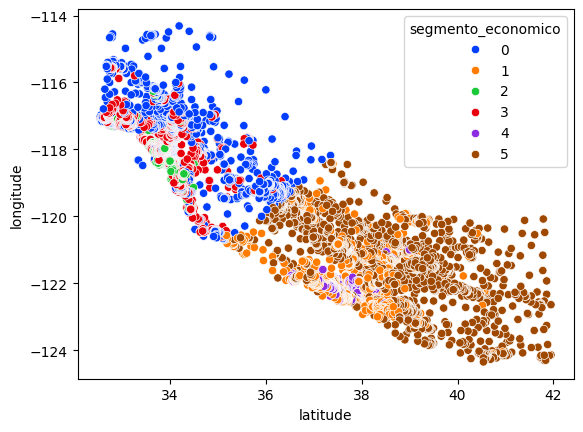

In [13]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=x, hue="segmento_economico",
               palette="bright")

Este gráfico de barras muestra la cantidad de viviendas en cada segmento económico.

<Axes: xlabel='segmento_economico', ylabel='count'>

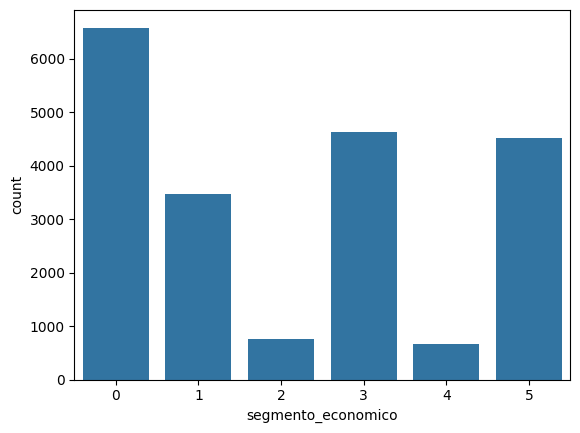

In [14]:
sb.countplot(x="segmento_economico", data=x)

Esta celda calcula el ingreso mediano promedio para cada segmento económico.

In [15]:
x.groupby(["segmento_economico"])["median_income"].mean()

,median_income
segmento_economico,
0,2.633187
1,4.629799
2,8.941455
3,4.921029
4,8.265194
5,2.509503
